In [1]:
# --! include root folder into PYTHONPATH ---------------------------------!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

In [2]:
# --! import Python libraries files -------------------!

import torch
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint
from typing import Tuple

import utils_data

In [3]:
# --! declare a class that implements online DMD as designed in https://github.com/haozhg/odmd --!

class OnlineDMD:
    """OnlineDMD is a class that implements online dynamic mode decomposition
    The time complexity (multiply–add operation for one iteration) is O(4n^2),
    and space complexity is O(2n^2), where n is the state dimension.

    Algorithm description:
        At time step t, define two matrix X(t) = [x(1),x(2),...,x(t)],
        Y(t) = [y(1),y(2),...,y(t)], that contain all the past snapshot pairs,
        where x(t), y(t) are the n dimensional state vector, y(t) = f(x(t)) is
        the image of x(t), f() is the dynamics.

        Here, if the (discrete-time) dynamics are given by z(t) = f(z(t-1)),
        then x(t), y(t) should be measurements correponding to consecutive
        states z(t-1) and z(t).

        We would like to update the DMD matrix A(t) recursively
        by efficient rank-1 updating online DMD algrithm.
        An exponential weighting factor can be used to place more weight on
        recent data.

    Usage:
        odmd = OnlineDMD(n, weighting)
        odmd.initialize(Xp, Yp) # optional
        odmd.update(x, y)
        evals, modes = odmd.computemodes()

    properties:
        n: state dimension
        weighting: weighting factor in (0,1]
        timestep: number of snapshot pairs processed (i.e., current time step)
        A: DMD matrix, size n by n

    methods:
        initialize(Xp, Yp), initialize online DMD algorithm with first p
                            snapshot pairs stored in (Xp, Yp), this func call is optional
        update(x, y), update DMD computation when new snapshot pair (x,y)
                            becomes available
        computemodes(), compute and return DMD eigenvalues and DMD modes

    Authors:
        Hao Zhang
        Clarence W. Rowley

    References:
        Zhang, Hao, Clarence W. Rowley, Eric A. Deem, and Louis N. Cattafesta.
        "Online dynamic mode decomposition for time-varying systems."
        SIAM Journal on Applied Dynamical Systems 18, no. 3 (2019): 1586-1609.

    Date created: April 2017
    """

    def __init__(self, n: int, weighting: float = 0.9) -> None:
        """Creat an object for online DMD
        Usage: odmd = OnlineDMD(n, weighting)

        Args:
            n (int): state dimension x(t) as in  z(t) = f(z(t-1)) or y(t) = f(t, x(t))
            weighting (float, optional): exponential weighting factor
                smaller value allows more adpative learning, 
                but too small weighting may result in model identification instability (relies only on limited recent snapshots). 
                Defaults to 0.9.
        """
        assert isinstance(n, int) and n >= 1
        weighting = float(weighting)
        assert weighting > 0 and weighting <= 1

        self.n = n
        self.weighting = weighting
        self.timestep = 0
        self.A = np.zeros([n, n])
        self._P = np.zeros([n, n])
        # initialize
        self._initialize()
        self.ready = False

    def _initialize(self) -> None:
        """Initialize online DMD with epsilon small (1e-15) ghost snapshot pairs before t=0"""
        epsilon = 1e-15
        alpha = 1.0 / epsilon
        self.A = np.random.randn(self.n, self.n)
        self._P = alpha * np.identity(self.n)  # inverse of cov(X)

    def initialize(self, Xp: np.ndarray, Yp: np.ndarray) -> None:
        """Initialize online DMD with first p (p >= n) snapshot pairs stored in (Xp, Yp)
        Usage: odmd.initialize(Xp, Yp)

        Args:
            Xp (np.ndarray): 2D array, shape (n, p), matrix [x(1),x(2),...x(p)]
            Yp (np.ndarray): 2D array, shape (n, p), matrix [y(1),y(2),...y(p)]
        """

        assert Xp is not None and Yp is not None
        Xp, Yp = np.array(Xp), np.array(Yp)
        assert Xp.shape == Yp.shape
        assert Xp.shape[0] == self.n
        # necessary condition for over-constrained initialization
        p = Xp.shape[1]
        assert p >= self.n and np.linalg.matrix_rank(Xp) == self.n

        weight = np.sqrt(self.weighting) ** range(p - 1, -1, -1)
        Xqhat, Yqhat = weight * Xp, weight * Yp
        self.A = Yqhat.dot(np.linalg.pinv(Xqhat))
        self._P = np.linalg.inv(Xqhat.dot(Xqhat.T)) / self.weighting
        self.timestep += p

        if self.timestep >= 2 * self.n:
            self.ready = True

    def update(self, x: np.ndarray, y: np.ndarray) -> None:
        """Update the DMD computation with a new pair of snapshots (x,y)
        Here, if the (discrete-time) dynamics are given by z(t) = f(z(t-1)),
        then (x,y) should be measurements correponding to consecutive states
        z(t-1) and z(t).
        Usage: odmd.update(x, y)

        Args:
            x (np.ndarray): 1D array, shape (n, ), x(t) as in y(t) = f(t, x(t))
            y (np.ndarray): 1D array, shape (n, ), y(t) as in y(t) = f(t, x(t))
        """
        assert x is not None and y is not None
        x, y = np.array(x), np.array(y)
        assert np.array(x).shape == np.array(y).shape
        assert np.array(x).shape[0] == self.n

        # compute P*x matrix vector product beforehand
        Px = self._P.dot(x)
        # compute gamma
        gamma = 1.0 / (1 + x.T.dot(Px))
        # update A
        self.A += np.outer(gamma * (y - self.A.dot(x)), Px)
        # update P, group Px*Px' to ensure positive definite
        self._P = (self._P - gamma * np.outer(Px, Px)) / self.weighting
        # ensure P is SPD by taking its symmetric part
        self._P = (self._P + self._P.T) / 2

        # time step + 1
        self.timestep += 1

        if self.timestep >= 2 * self.n:
            self.ready = True

    def computemodes(self) -> Tuple[np.ndarray, np.ndarray]:
        """Compute and return DMD eigenvalues and DMD modes at current time step
        Usage: evals, modes = odmd.computemodes()

        Raises:
            Exception: if Model not ready! Have not seen enough data!

        Returns:
            Tuple[np.ndarray, np.ndarray]: DMD eigenvalues (2D array) and DMD modes (2D array)
        """
        if not self.ready:
            raise Exception(f"Model not ready! Have not seen enough data!")
        evals, modes = np.linalg.eig(self.A)
        return evals, modes

In [4]:
# --! load test data --!

datadir            = '../../data/baselines/test_sim'
timeseries_nsample = 200

data = utils_data.read_datafile(f'{datadir}/eval', timeseries_nsample)

# --! normalize loaded data
mean         = torch.mean(data, dim=1, keepdim=True)
data         = data - mean
scaler       = utils_data.minmax_scaler(feature_range=(-1, 1))
data         = scaler.fit_transform(data).numpy()
jdata        = 0
timeseries   = data[jdata].T

x = timeseries[:, :-1]
y = timeseries[:, 1:]

n = x.shape[0]
m = x.shape[1]

In [5]:
# --! run prediction and forecast loops using online DMD --!

q    = 20
odmd = OnlineDMD(n, 0.7)
odmd.initialize(x[:, :q], y[:, :q])

# --! create an output buffer
odmd_o = np.empty((n, m))

# --! define state x and save the current state x in the output buffer
state        = x[:, 0]
odmd_o[:, 0] = state

# --! prediction start
pre_start = 75

# --! run a typical +1 prediction loop with a regular matrix A update
for j in range(1, pre_start):

    # --! update matrix A with a new measurement
    meas  = x[:, j]
    odmd.update(state, meas)

    # --! make +1 prediction step using the updated matrix A
    state = odmd.A.dot(state)
    odmd_o[:, j] = state

# --! define forecast horizon
pre_horizon = 50
pre_end     = pre_start + pre_horizon

# --! run a forecast loop
for j in range(pre_start, pre_end):
    state = odmd.A.dot(state)
    odmd_o[:, j] = state

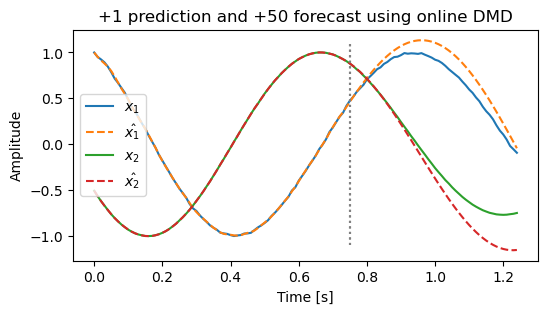

In [11]:
# --! display prediction and forecast results --!

dt = 0.01
t  = np.arange(0., pre_end*dt, dt)

plt.figure(figsize=(6,3))
plt.title(f'+1 prediction and +{pre_horizon} forecast using online DMD')
for j in range(n):
    plt.plot(t, timeseries[j, :pre_end], label='$x_{' + f'{j+1}' + '}$')
    plt.plot(t, odmd_o[j, :pre_end], linestyle='dashed', label='$\\hat{x_{' + f'{j+1}' + '}}$')
    plt.plot([t[pre_start], t[pre_start]], [-1.1, 1.1], linestyle='dotted', color='gray')
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')

plt.show()